In [8]:
import torch
import torch.nn as nn

from torch.utils.data  import DataLoader
from torchvision.datasets import MNIST
import torch.nn.functional as F
import torchvision.utils
from torch.utils.data import TensorDataset

from tqdm import tqdm
import numpy as np
import random
#import matplotlib
#matplotlib.use('qtagg')
#%matplotlib ipympl
import matplotlib.pyplot as plt

In [12]:
# load the custom MNIST provided for this assessment
# it is a .pt file containing tensors, not a torchvision MNIST dataset
import os

print("file size:", os.path.getsize('mnist_custom.pt'), "bytes (expected 112562040)")

d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)

for k, v in d.items():
    print(k, tuple(v.shape), v.dtype, "min", float(v.min()), "max", float(v.max()))

bs_train = 1000
bs_test  = 1000

train_dataset = TensorDataset(d['train_images'], d['train_labels'])
test_dataset  = TensorDataset(d['test_images'],  d['test_labels'])

train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,  num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=bs_test,  shuffle=False, num_workers=0)

# check one batch
x, y = next(iter(train_dataloader))
print("batch:", x.shape, y.shape)

file size: 112562040 bytes (expected 112562040)
train_images (60000, 1, 20, 20) torch.float32 min 0.0 max 1.0
train_labels (60000,) torch.int64 min 0.0 max 9.0
test_images (10000, 1, 20, 20) torch.float32 min 0.0 max 1.0
test_labels (10000,) torch.int64 min 0.0 max 9.0
batch: torch.Size([1000, 1, 20, 20]) torch.Size([1000])


In [13]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 5: 64x3x3 -> 256x1x1  (kernel 3 instead of 4, the feature map
            # is 3x3 here rather than 4x4 because the input is 20x20 not 28x28)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu,logvar = torch.chunk(x, 2, dim=1)
        return mu,logvar

In [14]:
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3  (mirrors the encoder's 3x3 feature map)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 3: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 4: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 5: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat  = self.decoder_backbone(z)
        # z shape: (batch_size, z_dim)
        return x_hat

In [15]:
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

In [16]:
# parameters
z_dim = 7   # the brief specifies 7 latent dimensions (the tutorial used 8)

model = cVAE(z_dim, num_classes = 10)
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)

print("\n---total number of parameters:")
print(sum(p.numel() for p in model.parameters()))

# check the shapes line up with the 20x20 input
x, y = next(iter(train_dataloader))
x = x[:4].to(device)
cond = F.one_hot(y[:4], num_classes=10).float().to(device)
x_hat, mu, logvar = model(x, cond)
print("input :", tuple(x.shape))
print("output:", tuple(x_hat.shape))
print("mu    :", tuple(mu.shape))


---total number of parameters:
350107
input : (4, 1, 20, 20)
output: (4, 1, 20, 20)
mu    : (4, 7)


In [17]:
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """
    # Reconstruction loss (MSE)
    recon_loss = 100*F.mse_loss(x_hat, x, reduction='mean')

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [20]:
import torch.optim as optim
from torchvision.utils import make_grid

def get_batch(batch, device,f_train=True,num_classes=10):
    # f_train to select if this is a batch for training or testing
    # not used here, but will be useful later
    x  = batch[0].to(device)
    cond  = batch[1].to(device)
    cond = F.one_hot(cond, num_classes=num_classes).float()
    return x,cond

def training_loop(model,train_dataloader,test_dataloader,nb_epoch):
    
    # optimizer
    optimizer = optim.AdamW(model.parameters(),
                            lr = 0.001,
                            eps=1e-5,fused=False,betas=(0.75,0.99))
    # loop over epochs
    losses = []
    for epoch in range(nb_epoch):
        print(f'----- Epoch {epoch+1}')
    
        # --------- train
        model.train()
        
        loss_train = 0
        idx  = 0
        pbar = tqdm(iterable=train_dataloader, unit="batch",desc='training', colour='GREEN')
        for batch in pbar:
            idx += 1
            if idx>100000:
                break

            x,cond = get_batch(batch, device,f_train=True)
    
            optimizer.zero_grad()
            x_hat,mu,logvar = model(x,cond)
            
            # compute the loss
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat,mu,logvar)
            loss_train += total_loss
    
            # backprop
            total_loss.backward()
            optimizer.step()
            
        loss_train /= idx
    
        
        # --------- test
        model.eval()
        
        loss_test = 0
        idx  = 0
        correct = 0
        N = 0
        pbar = tqdm(iterable=test_dataloader, unit="batch",desc=' testing', colour='CYAN')
        for batch in pbar:
            idx += 1
            if idx>20000:
                break

            x,cond = get_batch(batch, device,f_train=False)

            with torch.no_grad():
                mu,logvar = model.encode(x,cond)
                x_hat = model.decode(mu,cond)
                
            
            # compute the loss
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat,mu,logvar)
            loss_test += total_loss
            
        loss_test /= idx
    
        # # create an image for display
        toDisp = torch.cat((x[:10],x_hat[:10]))
        displayTraining = make_grid(toDisp, nrow = 10).permute(1, 2, 0).cpu() 
    
        # --------- update losses 
        losses.append([loss_train.detach().cpu(),loss_test.detach().cpu()])
        print(f'losses training: {losses[-1][0]}, testing: {losses[-1][1]}')
    
        # --- show reconstucted images
        #figure.add_subplot(2, 1, 2)
        plt.imshow(displayTraining)
        plt.title('testing data and reconstruction')
        plt.axis("off")
        plt.show()

    return losses

In [24]:
# Discriminator: tells apart real images from cVAE reconstructions.
# It mirrors the encoder backbone but outputs a single real/fake score, and is
# conditioned on the class label so it can also check the digit is consistent.
class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super(Discriminator, self).__init__()
        self.backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),   # 64*3*3 = 576
        )
        self.head = nn.Sequential(
            nn.Linear(576 + num_classes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x, cond):
        h = self.backbone(x)
        h = torch.cat([h, cond], dim=1)
        return self.head(h)          # raw logit, BCEWithLogitsLoss applies sigmoid

In [25]:
def compute_loss_with_disc(x, x_hat, mu, logvar, disc, cond, beta=0.1, gamma=1.0):
    """
    cVAE loss from the tutorial plus an adversarial term that pushes the decoder
    to produce reconstructions the discriminator judges as real.
    gamma controls how much the discriminator term contributes.
    """
    total_loss, recon_loss, kl_loss = compute_loss(x, x_hat, mu, logvar, beta)

    # generator side of the adversarial loss: we want D(x_hat) to be classified
    # as real (label 1)
    d_out = disc(x_hat, cond)
    adv_loss = F.binary_cross_entropy_with_logits(d_out, torch.ones_like(d_out))

    return total_loss + gamma * adv_loss, recon_loss, kl_loss, adv_loss

In [26]:
from torchvision.utils import make_grid

def training_loop_disc(model, disc, train_dataloader, test_dataloader, nb_epoch, gamma=1.0):

    # same optimiser settings as the tutorial for the cVAE
    optimizer = optim.AdamW(model.parameters(),
                            lr = 0.001,
                            eps=1e-5, fused=False, betas=(0.75,0.99))
    # separate optimiser for the discriminator
    optimizer_d = optim.AdamW(disc.parameters(),
                              lr = 0.0002,
                              eps=1e-5, fused=False, betas=(0.5,0.99))

    losses = []
    for epoch in range(nb_epoch):
        print(f'----- Epoch {epoch+1}')

        # --------- train
        model.train()
        disc.train()

        loss_train, loss_d_train, loss_adv_train = 0, 0, 0
        idx = 0
        pbar = tqdm(iterable=train_dataloader, unit="batch", desc='training', colour='GREEN')
        for batch in pbar:
            idx += 1
            x, cond = get_batch(batch, device, f_train=True)

            # ---- step 1: update the discriminator
            # it should call the real images real and the reconstructions fake
            with torch.no_grad():
                x_hat_detached, _, _ = model(x, cond)

            optimizer_d.zero_grad()
            d_real = disc(x, cond)
            d_fake = disc(x_hat_detached, cond)
            loss_d = (F.binary_cross_entropy_with_logits(d_real, torch.ones_like(d_real)) +
                      F.binary_cross_entropy_with_logits(d_fake, torch.zeros_like(d_fake))) / 2
            loss_d.backward()
            optimizer_d.step()

            # ---- step 2: update the cVAE
            # reconstruction + KL as before, plus the adversarial term
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x, cond)
            total_loss, recon_loss, kl_loss, adv_loss = compute_loss_with_disc(
                x, x_hat, mu, logvar, disc, cond, gamma=gamma)
            total_loss.backward()
            optimizer.step()

            loss_train += total_loss
            loss_d_train += loss_d
            loss_adv_train += adv_loss

        loss_train /= idx
        loss_d_train /= idx
        loss_adv_train /= idx

        # --------- test
        model.eval()
        disc.eval()

        loss_test = 0
        idx = 0
        pbar = tqdm(iterable=test_dataloader, unit="batch", desc=' testing', colour='CYAN')
        for batch in pbar:
            idx += 1
            x, cond = get_batch(batch, device, f_train=False)

            with torch.no_grad():
                mu, logvar = model.encode(x, cond)
                x_hat = model.decode(mu, cond)

            # the test loss uses the plain cVAE loss so it is directly comparable
            # with the baseline model
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat, mu, logvar)
            loss_test += total_loss

        loss_test /= idx

        # create an image for display
        toDisp = torch.cat((x[:10], x_hat[:10]))
        displayTraining = make_grid(toDisp, nrow=10).permute(1, 2, 0).cpu()

        losses.append([loss_train.detach().cpu(), loss_test.detach().cpu(),
                       loss_d_train.detach().cpu(), loss_adv_train.detach().cpu()])
        print(f'losses training: {losses[-1][0]:.4f}, testing: {losses[-1][1]:.4f}, '
              f'D: {losses[-1][2]:.4f}, adv: {losses[-1][3]:.4f}')

        plt.imshow(displayTraining)
        plt.title('testing data and reconstruction')
        plt.axis("off")
        plt.show()

    return losses

cVAE params: 350107
Discriminator params: 98561
----- Epoch 1


 testing: 100%|██████████| 10/10 [00:00<00:00, 145.72batch/s]

losses training: 11.8938, testing: 6.0428, D: 0.6430, adv: 0.7368


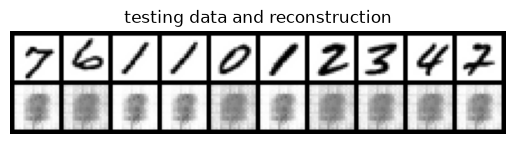

----- Epoch 2


 testing: 100%|██████████| 10/10 [00:00<00:00, 145.30batch/s]

losses training: 6.5407, testing: 5.3719, D: 0.5454, adv: 0.9147


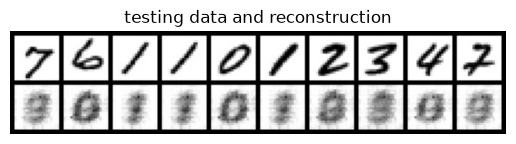

----- Epoch 3


 testing: 100%|██████████| 10/10 [00:00<00:00, 37.98batch/s]

losses training: 6.3123, testing: 5.0383, D: 0.5404, adv: 1.0323


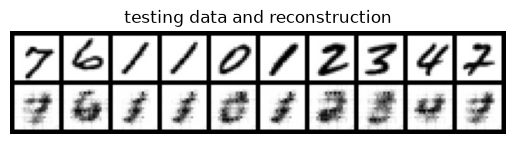

----- Epoch 4


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.16batch/s]

losses training: 5.5567, testing: 4.2897, D: 0.5949, adv: 0.8880


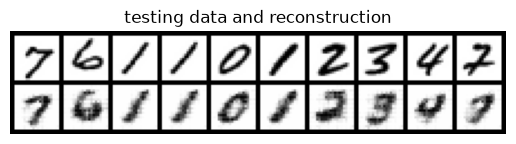

----- Epoch 5


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.03batch/s]

losses training: 5.0358, testing: 3.8747, D: 0.6414, adv: 0.8035


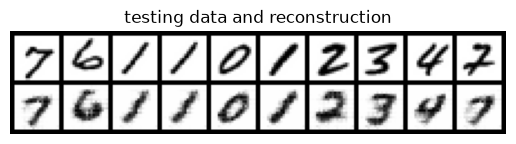

----- Epoch 6


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.51batch/s]

losses training: 4.7401, testing: 3.6082, D: 0.6555, adv: 0.7875


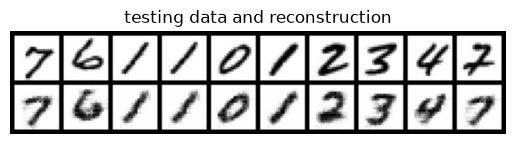

----- Epoch 7


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.43batch/s]

losses training: 4.5401, testing: 3.4881, D: 0.6535, adv: 0.7834


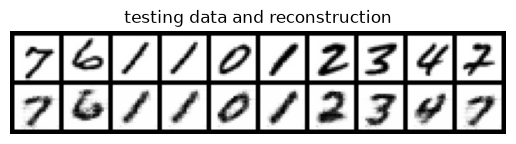

----- Epoch 8


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.48batch/s]

losses training: 4.3858, testing: 3.3432, D: 0.6535, adv: 0.7805


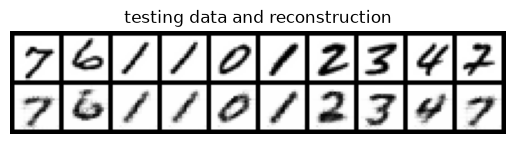

----- Epoch 9


 testing: 100%|██████████| 10/10 [00:00<00:00, 145.01batch/s]

losses training: 4.2690, testing: 3.1865, D: 0.6541, adv: 0.7818


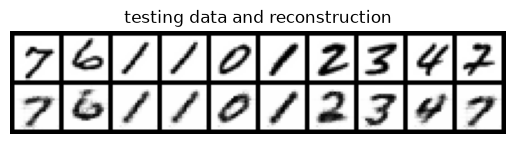

----- Epoch 10


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.96batch/s]

losses training: 4.1714, testing: 3.0765, D: 0.6598, adv: 0.7851


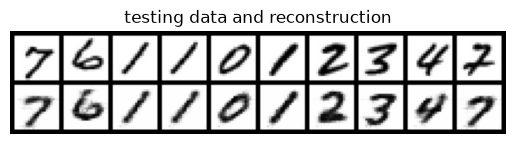

----- Epoch 11


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.06batch/s]

losses training: 4.0722, testing: 2.9500, D: 0.6614, adv: 0.7684


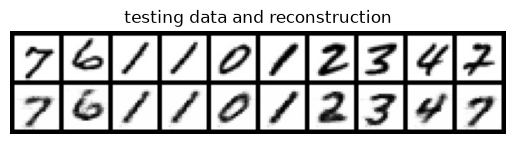

----- Epoch 12


 testing: 100%|██████████| 10/10 [00:00<00:00, 38.07batch/s]

losses training: 3.9870, testing: 2.9081, D: 0.6644, adv: 0.7631


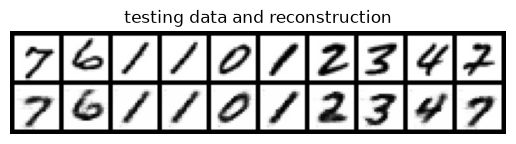

----- Epoch 13


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.92batch/s]

losses training: 3.9486, testing: 2.8256, D: 0.6670, adv: 0.7698


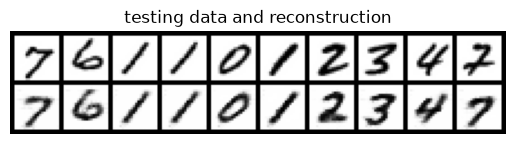

----- Epoch 14


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.98batch/s]

losses training: 3.8839, testing: 2.8027, D: 0.6615, adv: 0.7599


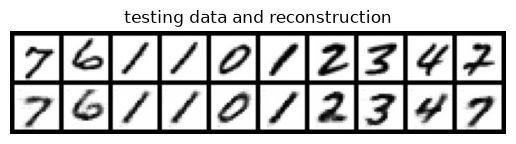

----- Epoch 15


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.89batch/s]

losses training: 3.8555, testing: 2.7351, D: 0.6644, adv: 0.7676


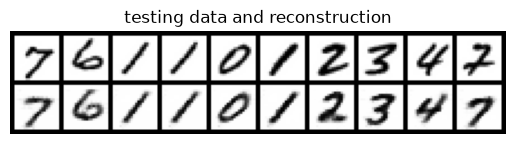

----- Epoch 16


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.95batch/s]

losses training: 3.8122, testing: 2.7180, D: 0.6619, adv: 0.7638


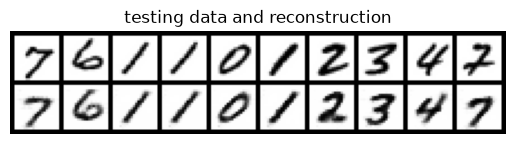

----- Epoch 17


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.55batch/s]

losses training: 3.7830, testing: 2.7655, D: 0.6605, adv: 0.7670


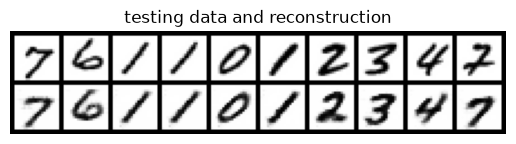

----- Epoch 18


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.78batch/s]

losses training: 3.7597, testing: 2.6909, D: 0.6624, adv: 0.7664


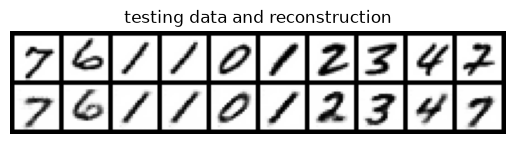

----- Epoch 19


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.71batch/s]

losses training: 3.7347, testing: 2.6398, D: 0.6604, adv: 0.7665


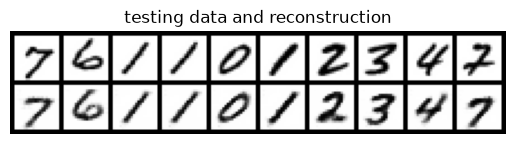

----- Epoch 20


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.29batch/s]

losses training: 3.7194, testing: 2.6483, D: 0.6617, adv: 0.7680


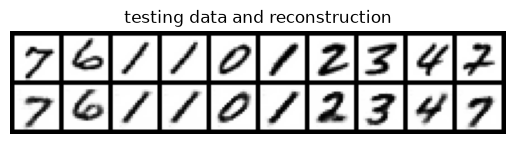

----- Epoch 21


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.70batch/s]

losses training: 3.6974, testing: 2.6095, D: 0.6604, adv: 0.7652


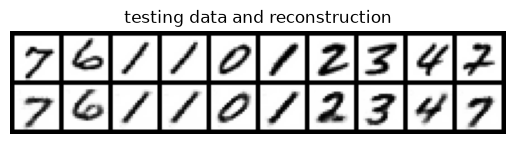

----- Epoch 22


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.21batch/s]

losses training: 3.6799, testing: 2.5804, D: 0.6635, adv: 0.7664


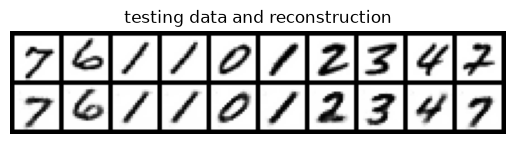

----- Epoch 23


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.10batch/s]

losses training: 3.6492, testing: 2.5495, D: 0.6656, adv: 0.7607


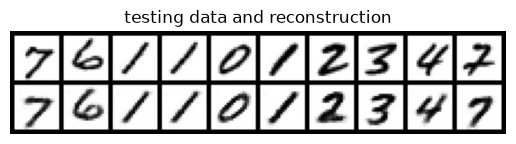

----- Epoch 24


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.55batch/s]

losses training: 3.6311, testing: 2.5162, D: 0.6658, adv: 0.7592


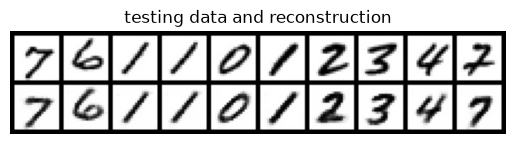

----- Epoch 25


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.58batch/s]

losses training: 3.6045, testing: 2.5086, D: 0.6669, adv: 0.7541


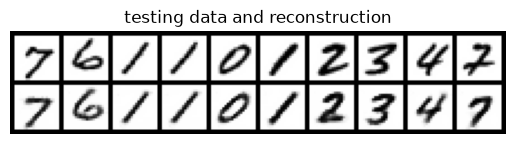

----- Epoch 26


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.89batch/s]

losses training: 3.5884, testing: 2.4801, D: 0.6675, adv: 0.7580


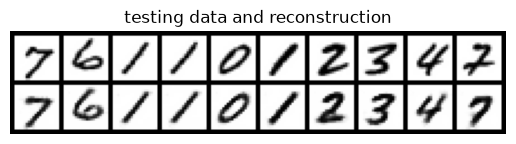

----- Epoch 27


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.69batch/s]

losses training: 3.5721, testing: 2.5256, D: 0.6668, adv: 0.7561


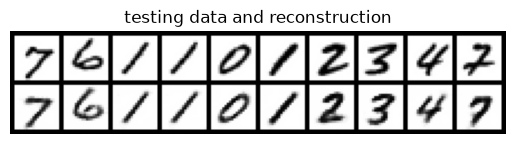

----- Epoch 28


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.96batch/s]

losses training: 3.5553, testing: 2.4720, D: 0.6658, adv: 0.7590


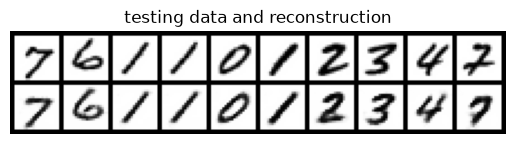

----- Epoch 29


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.77batch/s]

losses training: 3.5348, testing: 2.4481, D: 0.6674, adv: 0.7533


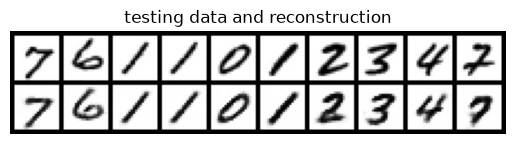

----- Epoch 30


 testing: 100%|██████████| 10/10 [00:00<00:00, 140.52batch/s]

losses training: 3.5240, testing: 2.4653, D: 0.6660, adv: 0.7559


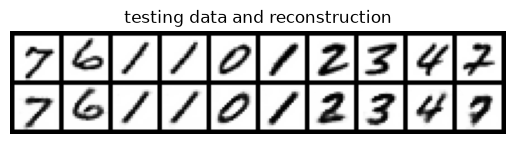

----- Epoch 31


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.47batch/s]

losses training: 3.5119, testing: 2.3892, D: 0.6667, adv: 0.7580


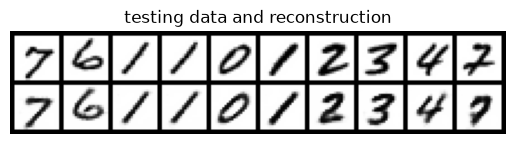

----- Epoch 32


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.32batch/s]

losses training: 3.5083, testing: 2.4205, D: 0.6653, adv: 0.7595


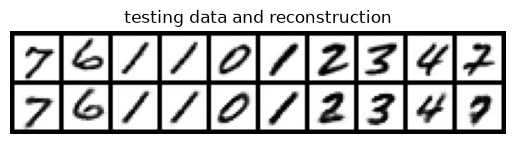

----- Epoch 33


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.08batch/s]

losses training: 3.4880, testing: 2.4092, D: 0.6652, adv: 0.7574


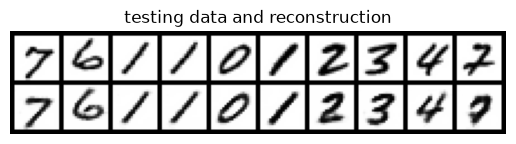

----- Epoch 34


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.96batch/s]

losses training: 3.4727, testing: 2.4313, D: 0.6655, adv: 0.7564


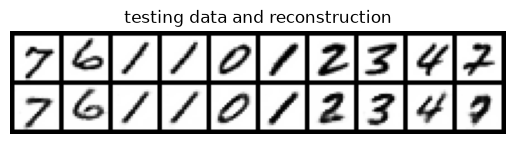

----- Epoch 35


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.80batch/s]

losses training: 3.4738, testing: 2.3877, D: 0.6651, adv: 0.7593


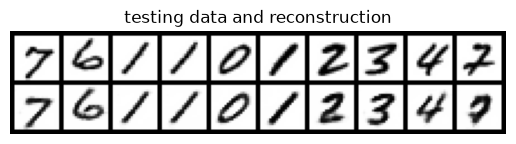

----- Epoch 36


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.61batch/s]

losses training: 3.4551, testing: 2.3829, D: 0.6656, adv: 0.7584


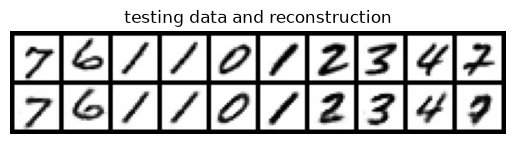

----- Epoch 37


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.93batch/s]

losses training: 3.4539, testing: 2.3771, D: 0.6648, adv: 0.7589


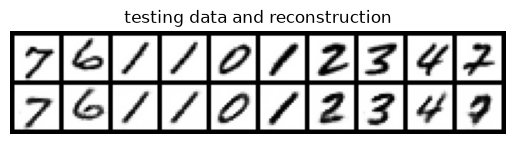

----- Epoch 38


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.43batch/s]

losses training: 3.4482, testing: 2.3350, D: 0.6654, adv: 0.7611


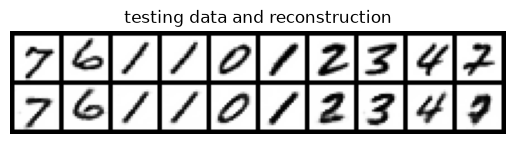

----- Epoch 39


 testing: 100%|██████████| 10/10 [00:00<00:00, 138.24batch/s]

losses training: 3.4400, testing: 2.3411, D: 0.6650, adv: 0.7563


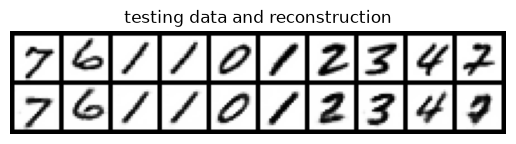

----- Epoch 40


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.19batch/s]

losses training: 3.4376, testing: 2.3608, D: 0.6663, adv: 0.7605


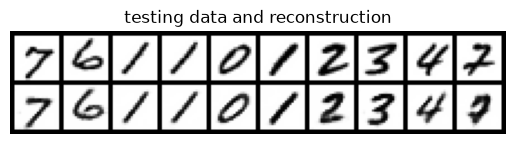

----- Epoch 41


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.20batch/s]

losses training: 3.4169, testing: 2.3551, D: 0.6643, adv: 0.7563


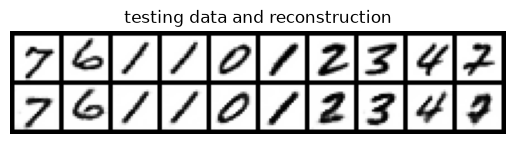

----- Epoch 42


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.45batch/s]

losses training: 3.4282, testing: 2.3274, D: 0.6653, adv: 0.7617


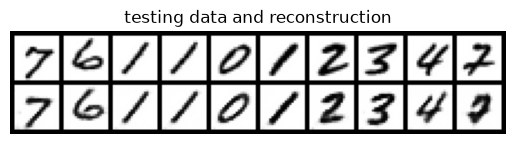

----- Epoch 43


 testing: 100%|██████████| 10/10 [00:00<00:00, 145.17batch/s]

losses training: 3.4094, testing: 2.3193, D: 0.6648, adv: 0.7551


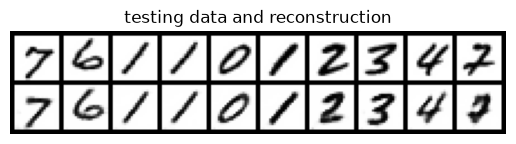

----- Epoch 44


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.81batch/s]

losses training: 3.4192, testing: 2.3571, D: 0.6665, adv: 0.7638


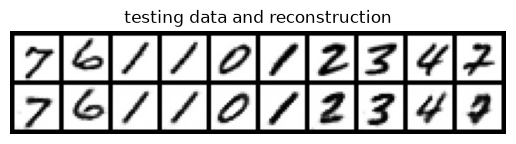

----- Epoch 45


 testing: 100%|██████████| 10/10 [00:00<00:00, 144.20batch/s]

losses training: 3.4048, testing: 2.3272, D: 0.6655, adv: 0.7596


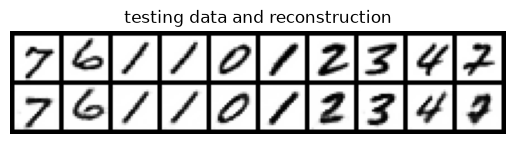

----- Epoch 46


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.33batch/s]

losses training: 3.4024, testing: 2.3403, D: 0.6639, adv: 0.7608


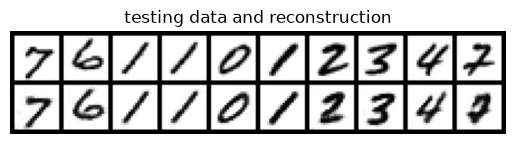

----- Epoch 47


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.08batch/s]

losses training: 3.3962, testing: 2.3138, D: 0.6648, adv: 0.7577


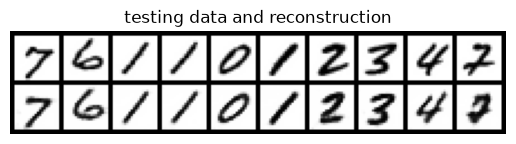

----- Epoch 48


 testing: 100%|██████████| 10/10 [00:00<00:00, 142.44batch/s]

losses training: 3.3912, testing: 2.2950, D: 0.6650, adv: 0.7624


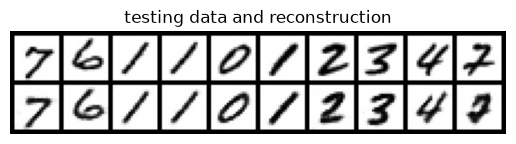

----- Epoch 49


 testing: 100%|██████████| 10/10 [00:00<00:00, 140.47batch/s]

losses training: 3.3889, testing: 2.3025, D: 0.6651, adv: 0.7601


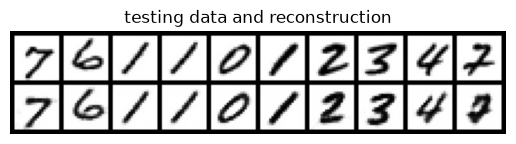

----- Epoch 50


 testing: 100%|██████████| 10/10 [00:00<00:00, 143.33batch/s]


losses training: 3.3743, testing: 2.2750, D: 0.6658, adv: 0.7562


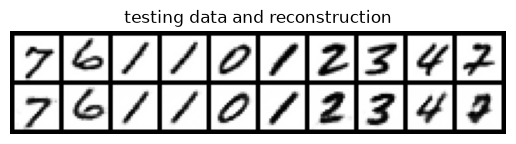

In [27]:
# create the models
torch.manual_seed(0)
model_disc = cVAE(z_dim, num_classes=10).to(device)
disc = Discriminator(num_classes=10).to(device)

print("cVAE params:", sum(p.numel() for p in model_disc.parameters()))
print("Discriminator params:", sum(p.numel() for p in disc.parameters()))

losses_disc = training_loop_disc(model_disc, disc, train_dataloader, test_dataloader,
                                nb_epoch=50, gamma=1.0)

In [28]:
import pickle

torch.save(model_disc.state_dict(), 'cvae_disc.pth')
torch.save(disc.state_dict(), 'discriminator.pth')

with open('results_disc.pkl', 'wb') as f:
    pickle.dump({'losses': [[float(v) for v in row] for row in losses_disc]}, f)

print("saved cvae_disc.pth, discriminator.pth and results_disc.pkl")

saved cvae_disc.pth, discriminator.pth and results_disc.pkl


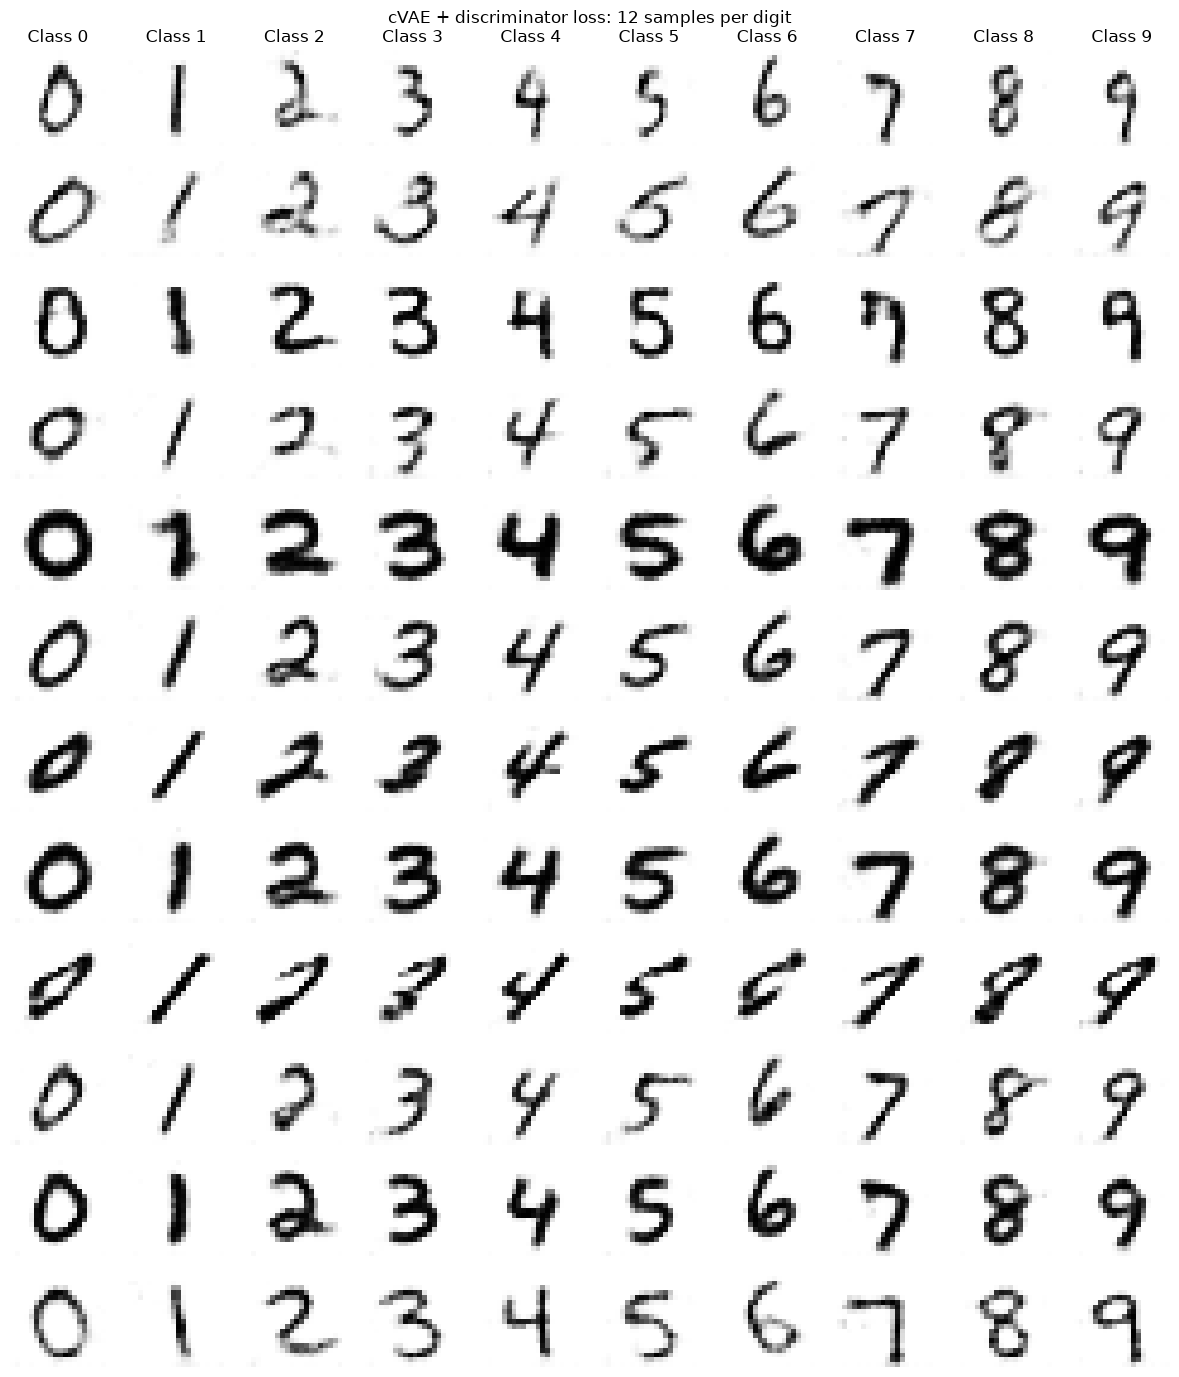

In [29]:
# same grid as the baseline, using the SAME latent vectors so the comparison is fair
num_samples = 12

model_disc.eval()
with torch.no_grad():
    all_conditions = torch.eye(10).to(device)

    torch.manual_seed(0)   # identical seed to the baseline grid
    z_cond = torch.randn(num_samples, z_dim).to(device)

    all_xhat_disc = []
    for cond in all_conditions:
        x_hat = model_disc.decode(z_cond, cond.repeat(z_cond.shape[0],1)).cpu()
        all_xhat_disc.append(x_hat)
    all_xhat_disc = torch.stack(all_xhat_disc)

fig, axes = plt.subplots(num_samples, 10, figsize=(12, 14))
for c in range(10):
    for i in range(num_samples):
        axes[i, c].imshow(all_xhat_disc[c, i].squeeze(), cmap='gray')
        if i == 0:
            axes[i, c].set_title(f'Class {c}')
        axes[i, c].axis('off')
plt.suptitle('cVAE + discriminator loss: 12 samples per digit')
plt.tight_layout()
plt.savefig('grid_disc.png', dpi=150, bbox_inches='tight')
plt.show()

with open('samples_disc.pkl', 'wb') as f:
    pickle.dump({'z': z_cond.cpu(), 'samples': all_xhat_disc}, f)